In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm import tqdm

from net import net

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


In [2]:
domain_length = 6.0
domain_width = 2.0
obstacle_x0 = 2.0
obstacle_x1 = 3.0
obstacle_y0 = 0.0
obstacle_y1 = 1.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x_min, x_max = 0.0, domain_length
y_min, y_max = 0.0, domain_width
t_min, t_max = 0.0, 10.0
nx, ny = 60, 40

x_centers = np.linspace(x_min + (x_max - x_min)/(2*nx), x_max - (x_max - x_min)/(2*nx), nx, dtype=np.float32)
y_centers = np.linspace(y_min + (y_max - y_min)/(2*ny), y_max - (y_max - y_min)/(2*ny), ny, dtype=np.float32)
X_grid, Y_grid = np.meshgrid(x_centers, y_centers)

def normalize_input(X):
    X_norm = np.copy(X)
    X_norm[:, 0] = (X[:, 0] - x_min) / (x_max - x_min)
    X_norm[:, 1] = (X[:, 1] - y_min) / (y_max - y_min)
    X_norm[:, 2] = (X[:, 2] - t_min) / (t_max - t_min)
    return X_norm

def unnormalize_input(X_norm):
    X = np.copy(X_norm)
    X[:, 0] = X_norm[:, 0] * (x_max - x_min) + x_min
    X[:, 1] = X_norm[:, 1] * (y_max - y_min) + y_min
    X[:, 2] = X_norm[:, 2] * (t_max - t_min) + t_min
    return X

def magnitude(vector_field):
    reshaped = vector_field.reshape((ny, nx, 2))
    x = reshaped[:, :, 0]
    y = reshaped[:, :, 1]
    return np.sqrt(x**2 + y**2)

Using device: cuda


In [3]:
# Training hyperparameters
LEARNING_RATE = 1e-4
BATCH_SIZE = 2**20
EPOCHS = 200
TRAINING_OUTPUT_DIR = "train_dir_pytorch/"
MODEL_BASE_NAME = "ns_obstacle_pytorch_norm"

data_npz = np.load('training_data.npz')
X_train_np = data_npz['X_train'].astype(np.float32)
Y_train_np = data_npz['Y_train'].astype(np.float32)


#filter out the data points that are inside the obstacle
obstacle_mask = ~((X_train_np[:, 0] >= obstacle_x0) & (X_train_np[:, 0] <= obstacle_x1) &
                  (X_train_np[:, 1] >= obstacle_y0) & (X_train_np[:, 1] <= obstacle_y1))
X_train_np = X_train_np[obstacle_mask]
Y_train_np = Y_train_np[obstacle_mask]

# Normalize input data
X_train_np = normalize_input(X_train_np)

train_dataset = TensorDataset(torch.from_numpy(X_train_np), torch.from_numpy(Y_train_np))
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    generator=torch.Generator(device=device))

model = net.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.5, verbose=True)

print("Starting training...")
os.makedirs(TRAINING_OUTPUT_DIR, exist_ok=True)
best_loss = float('inf')
loss_history = []
patience = 0
early_stopping = 50

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0.0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False)

    for inputs, targets in progress_bar:
        inputs, targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)

        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
    
    avg_epoch_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_epoch_loss)
    scheduler.step(avg_epoch_loss) # LR scheduler step

    print(f"Epoch [{epoch+1}/{EPOCHS}], Average Loss: {avg_epoch_loss:.8f}")

    # Save checkpoint if it's the best model so far
    if avg_epoch_loss < best_loss:
        best_loss = avg_epoch_loss
        patience = 0

        if epoch > 200:
            checkpoint_path = os.path.join(TRAINING_OUTPUT_DIR, f"{MODEL_BASE_NAME}_best.pt")
            torch.save(model.state_dict(), checkpoint_path)
            print(f"New best model saved to {checkpoint_path} with loss {best_loss:.8f}")
    else:
        patience += 1
        if patience >= early_stopping:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

print("Training finished.")

/home/dan/venvs/torch/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Starting training...


Epoch [1/200], Average Loss: 0.22665570


Epoch [2/200], Average Loss: 0.19505212


Epoch [3/200], Average Loss: 0.17196423


...

Epoch [196/200], Average Loss: 0.07264815


Epoch [197/200], Average Loss: 0.07258307


Epoch [198/200], Average Loss: 0.07250690


Epoch [199/200], Average Loss: 0.07247954


Epoch [200/200], Average Loss: 0.07248861
Training finished.


In [4]:
final_model_path = os.path.join(TRAINING_OUTPUT_DIR, f"{MODEL_BASE_NAME}_final.pt")
torch.save(model.state_dict(), final_model_path)
print(f"Final model saved to: {final_model_path}")

Final model saved to: train_dir_pytorch/ns_obstacle_pytorch_norm_final.pt


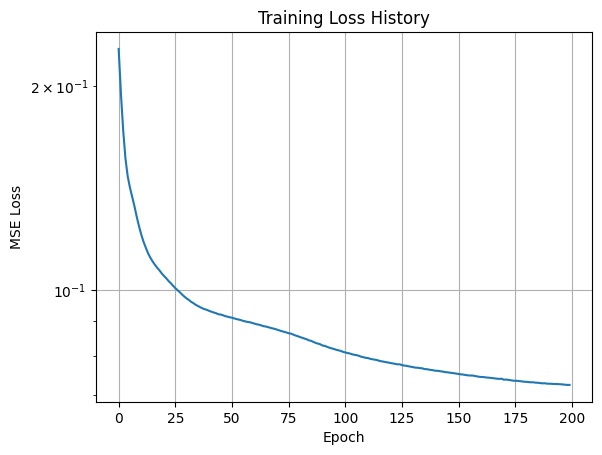

In [52]:
plt.figure()
plt.plot(loss_history)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss History')
plt.yscale('log')
plt.grid(True)
plt.savefig(os.path.join(TRAINING_OUTPUT_DIR, "loss_history.png"))
plt.show()

In [28]:
def model_predict(x_mesh, y_mesh, time=0.0):

    n_points_mesh = len(x_mesh.flatten())
    t_values_mesh = np.full(n_points_mesh, time, dtype=np.float32)
    
    points_to_predict_np = np.vstack((x_mesh.flatten(), y_mesh.flatten(), t_values_mesh)).T
    # normalize the input points
    points_to_predict_np = normalize_input(points_to_predict_np)
    points_to_predict_torch = torch.from_numpy(points_to_predict_np).to(device)

    with torch.no_grad():
        predictions = model(points_to_predict_torch).cpu().numpy()

    u_pred = predictions[:, 0].reshape(x_mesh.shape)
    v_pred = predictions[:, 1].reshape(x_mesh.shape)
    p_pred = predictions[:, 2].reshape(x_mesh.shape)

    Velocity = np.column_stack([u_pred.flatten(), v_pred.flatten()])
    Pressure = p_pred.flatten()

    return Velocity, Pressure

In [29]:
def update_plot(ax, field_data, time_value, field_name, vmin=None, vmax=None, cmap='coolwarm'):
    ax.clear()
    field_reshaped = field_data.reshape(ny, nx)
    
    im = ax.imshow(field_reshaped, cmap=cmap, origin='lower', 
                   extent=(x_min, x_max, y_min, y_max),
                   vmin=vmin, vmax=vmax)
    
    ax.add_patch(plt.Rectangle((obstacle_x0, obstacle_y0), 
                              obstacle_x1-obstacle_x0, 
                              obstacle_y1-obstacle_y0,
                              color='white', alpha=0.7))
    
    ax.set_title(f'{field_name} at t = {time_value:.2f}s')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    return [im]

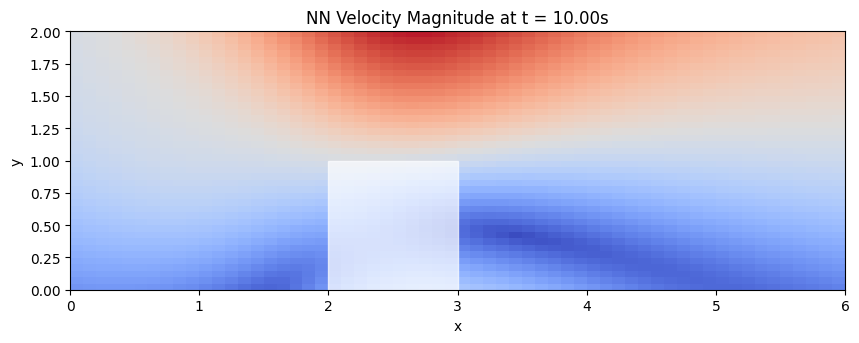

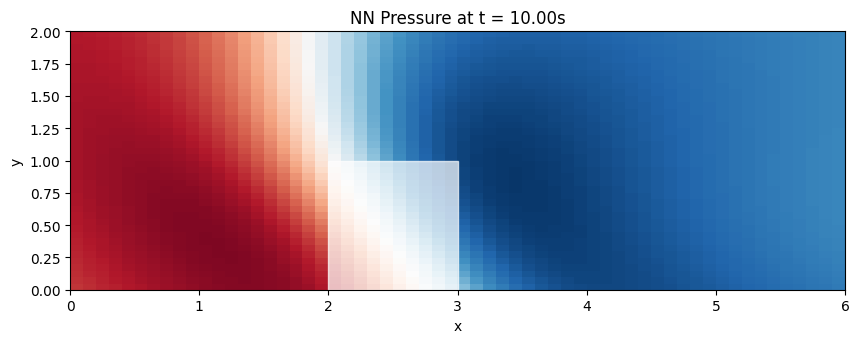

In [46]:
time_points = np.linspace(0, 10, 200)
nn_vel_mags = []
nn_pressures = []

for t in time_points:
    vel, press = model_predict(X_grid, Y_grid, time=t)
    nn_vel_mags.append(magnitude(vel).flatten())
    nn_pressures.append(press)

# NN velocity animation
fig_nn_vel, ax_nn_vel = plt.subplots(figsize=(10, 6))
nn_v_min, nn_v_max = np.min(nn_vel_mags), np.max(nn_vel_mags)

def animate_nn_velocity(frame):
    return update_plot(ax_nn_vel, nn_vel_mags[frame], time_points[frame],
                      'NN Velocity Magnitude', vmin=nn_v_min, vmax=nn_v_max)

ani_nn_vel = FuncAnimation(fig_nn_vel, animate_nn_velocity, frames=len(time_points), blit=True)
ani_nn_vel.save(os.path.join(TRAINING_OUTPUT_DIR, 'nn_velocity_animation.mp4'), writer='ffmpeg', fps=20)

# NN pressure animation
fig_nn_press, ax_nn_press = plt.subplots(figsize=(10, 6))
nn_p_min, nn_p_max = np.min(nn_pressures), np.max(nn_pressures)

def animate_nn_pressure(frame):
    return update_plot(ax_nn_press, nn_pressures[frame], time_points[frame],
                      'NN Pressure', vmin=nn_p_min, vmax=nn_p_max, cmap='RdBu_r')

ani_nn_press = FuncAnimation(fig_nn_press, animate_nn_pressure, frames=len(time_points), blit=True)
ani_nn_press.save(os.path.join(TRAINING_OUTPUT_DIR, 'nn_pressure_animation.mp4'), writer='ffmpeg', fps=20)

In [9]:
!jupyter nbconvert --to script 'offline-training-no-deepxde.ipynb'

[NbConvertApp] Converting notebook offline-training-no-deepxde.ipynb to script
[NbConvertApp] Writing 7907 bytes to offline-training-no-deepxde.py
